In [10]:
import pickle, torch
import yfinance as yf
import mplfinance as mpf
import matplotlib.pyplot as plt

In [5]:
checkpoint = torch.load('candle_model.pt', weights_only=False)

W1 = checkpoint['W1'].requires_grad_(False)
b1 = checkpoint['b1'].requires_grad_(False)
W2 = checkpoint['W2'].requires_grad_(False)
b2 = checkpoint['b2'].requires_grad_(False)
scaler = checkpoint['scaler']

def forward_pass(X):
    hidden = torch.relu(torch.matmul(X, W1) + b1)
    return torch.matmul(hidden, W2) + b2


def predict(open_, high, low, close, volume):
    x = scaler.transform([[close, high, low, open_, volume]])
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        logits = forward_pass(x_tensor)
    pred = torch.argmax(logits, dim=1).item()
    pattern_map = {0: 'No pattern', 1: 'Doji', 2: 'Hammer', 3: 'Engulfing'}
    return pattern_map[pred]

In [9]:
ticker = yf.Ticker("^GDAXI")
recent = ticker.history(period="15d").tail(10)  # fetch a bit extra to ensure 10 trading days

pattern_map = {0: 'No pattern', 1: 'Doji', 2: 'Hammer', 3: 'Engulfing'}

for date, row in recent.iterrows():
    x = scaler.transform([[row['Close'], row['High'], row['Low'], row['Open'], row['Volume']]])
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        logits = forward_pass(x_tensor)
    pred = torch.argmax(logits, dim=1).item()
    print(f"{date.date()}  →  {pattern_map[pred]}")

2026-05-20  →  No pattern
2026-05-21  →  No pattern
2026-05-22  →  No pattern
2026-05-25  →  No pattern
2026-05-26  →  No pattern
2026-05-27  →  No pattern
2026-05-28  →  No pattern
2026-05-29  →  No pattern
2026-06-01  →  No pattern
2026-06-02  →  No pattern


C:\Users\USER\candle_classifier\candle_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\USER\candle_classifier\candle_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\USER\candle_classifier\candle_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\USER\candle_classifier\candle_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\USER\candle_classifier\candle_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but St

C:\Users\USER\candle_classifier\candle_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\USER\candle_classifier\candle_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\USER\candle_classifier\candle_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\USER\candle_classifier\candle_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\USER\candle_classifier\candle_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but St

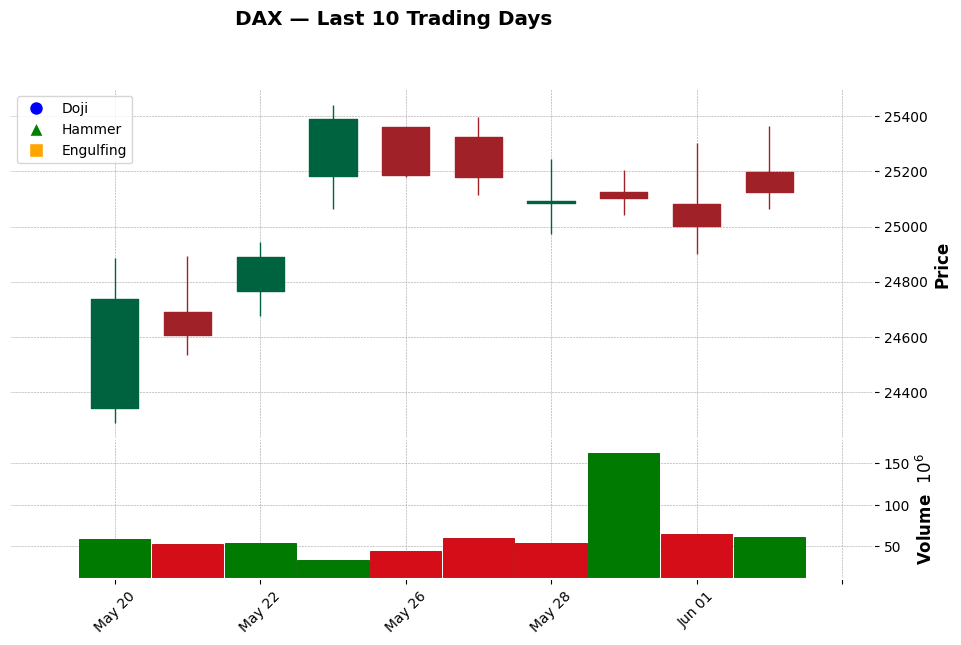

In [12]:
# Fetch data
ticker = yf.Ticker("^GDAXI")
recent = ticker.history(period="15d").tail(10)

pattern_map = {0: 'No pattern', 1: 'Doji', 2: 'Hammer', 3: 'Engulfing'}
colors     = {0: None, 1: 'blue', 2: 'green', 3: 'orange'}
markers    = {0: None, 1: 'o', 2: '^', 3: 's'}

# Run predictions
results = []
for date, row in recent.iterrows():
    x = scaler.transform([[row['Close'], row['High'], row['Low'], row['Open'], row['Volume']]])
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        logits = forward_pass(x_tensor)
    pred = torch.argmax(logits, dim=1).item()
    results.append(pred)

# Build marker overlays (only for non-zero patterns)
apds = []
for pattern_id in [1, 2, 3]:
    marker_prices = [
        recent.iloc[i]['Low'] * 0.995  # place marker just below the candle
        if results[i] == pattern_id else float('nan')
        for i in range(len(results))
    ]
    if any(p == pattern_id for p in results):
        apds.append(mpf.make_addplot(
            marker_prices,
            type='scatter',
            marker=markers[pattern_id],
            markersize=100,
            color=colors[pattern_id],
            label=pattern_map[pattern_id]
        ))

# Plot
fig, axes = mpf.plot(
    recent,
    type='candle',
    style='charles',
    title='DAX — Last 10 Trading Days',
    ylabel='Price',
    volume=True,
    addplot=apds if apds else [],
    returnfig=True,
    figsize=(12, 7)
)

# Add legend manually
legend_handles = [
    plt.Line2D([0], [0], marker=markers[pid], color='w',
               markerfacecolor=colors[pid], markersize=10,
               label=pattern_map[pid])
    for pid in [1, 2, 3]
]
axes[0].legend(handles=legend_handles, loc='upper left')

plt.tight_layout()
plt.savefig('dax_patterns.png', dpi=150)
plt.show()